In [35]:
import pandas as pd
from datetime import timedelta

# ----------------------------
# PARAMETERS
# ----------------------------
LEVERAGE = 2.0
HOLD_DAYS = 30

TRADES_FILE = "../data/trades_export_crowd.csv"
PRICES_FILE = "../data/perps_prices_19.csv"

# ----------------------------
# LOAD DATA
# ----------------------------
trades = pd.read_csv(TRADES_FILE)
prices = pd.read_csv(PRICES_FILE)

# Parse dates (MAKE BOTH UTC)
trades["open_date"] = pd.to_datetime(trades["open_date"], utc=True)
trades["close_date"] = pd.to_datetime(trades["close_date"], utc=True)

prices["time"] = pd.to_datetime(prices["time"], utc=True)

# Normalize names
trades["token"] = trades["token"].str.upper()
prices["perp"] = prices["perp"].str.upper()


# ----------------------------
# LIQUIDATION FUNCTIONS
# ----------------------------
def liquidation_price(entry_price, side, leverage):
    if side == "LONG":
        return entry_price * (1 - 1 / leverage)
    elif side == "SHORT":
        return entry_price * (1 + 1 / leverage)
    else:
        raise ValueError("Unknown side")

def check_liquidation(trade, price_df):
    token = trade["token"]
    side = trade["side"]
    entry_price = trade["effective_open"]
    start = trade["open_date"]
    end = start + timedelta(days=HOLD_DAYS)

    liq_price = liquidation_price(entry_price, side, LEVERAGE)

    # Select prices in the holding window
    p = price_df[
        (price_df["perp"] == token) &
        (price_df["time"] >= start) &
        (price_df["time"] <= end)
    ].sort_values("time")

    if p.empty:
        return pd.Series({
            "liquidated": False,
            "liquidation_date": pd.NaT,
            "liq_price": liq_price,
            "worst_price": None
        })

    if side == "LONG":
        breached = p[p["close"] <= liq_price]
        worst_price = p["close"].min()
    else:  # SHORT
        breached = p[p["close"] >= liq_price]
        worst_price = p["close"].max()

    if not breached.empty:
        return pd.Series({
            "liquidated": True,
            "liquidation_date": breached.iloc[0]["time"],
            "liq_price": liq_price,
            "worst_price": worst_price
        })

    return pd.Series({
        "liquidated": False,
        "liquidation_date": pd.NaT,
        "liq_price": liq_price,
        "worst_price": worst_price
    })

# ----------------------------
# RUN ANALYSIS
# ----------------------------
liq_results = trades.apply(
    lambda row: check_liquidation(row, prices),
    axis=1
)

results = pd.concat([trades, liq_results], axis=1)

# ----------------------------
# STATISTICS
# ----------------------------
stats = {
    "total_trades": len(results),
    "liquidated_trades": results["liquidated"].sum(),
    "liquidation_rate_%": 100 * results["liquidated"].mean(),
}

print("\n=== LIQUIDATION STATS (2x leverage) ===")
for k, v in stats.items():
    print(f"{k}: {v}")

# ----------------------------
# SAVE OUTPUT
# ----------------------------
results.to_csv("../data/trades_with_liquidations_2x.csv", index=False)
print("\nSaved: trades_with_liquidations_2x.csv")



=== LIQUIDATION STATS (2x leverage) ===
total_trades: 889
liquidated_trades: 67
liquidation_rate_%: 7.536557930258718

Saved: trades_with_liquidations_2x.csv


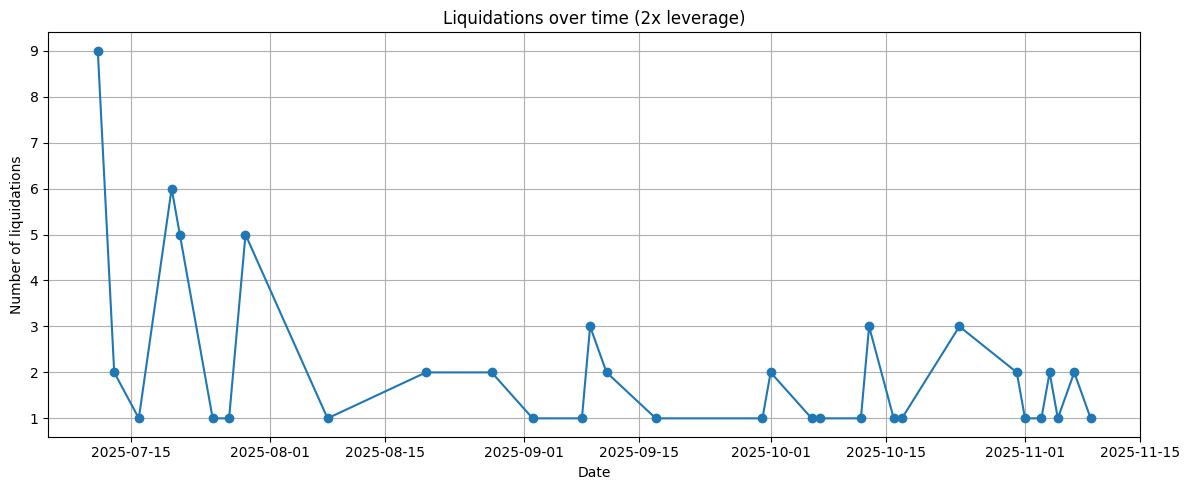

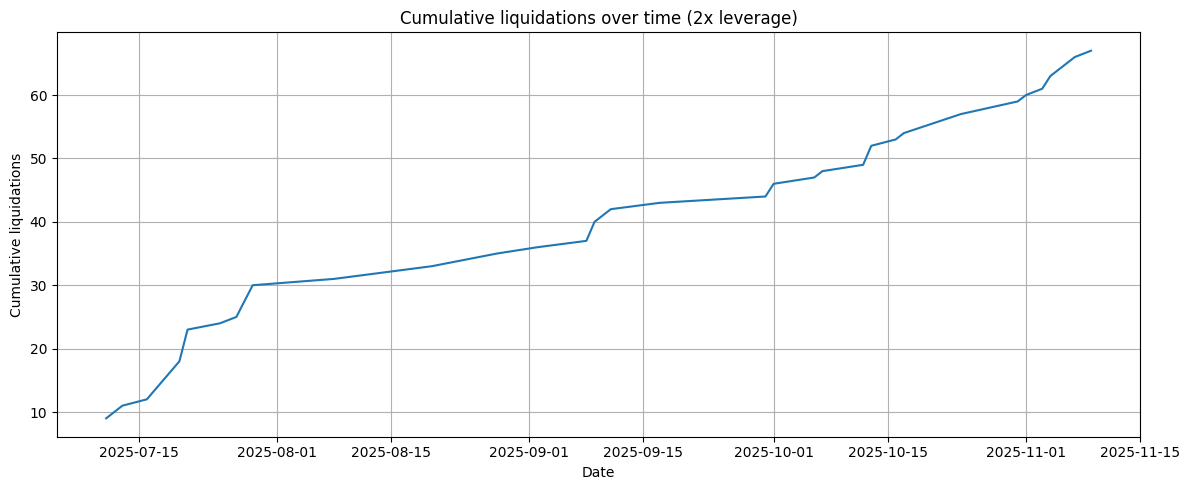

In [36]:
import matplotlib.pyplot as plt

# ----------------------------
# PREPARE LIQUIDATION SERIES
# ----------------------------
liq = results[results["liquidated"]].copy()

# Drop timezone for plotting clarity (optional)
liq["liquidation_date"] = liq["liquidation_date"].dt.tz_localize(None)

# Count liquidations per day
liq_per_day = (
    liq
    .groupby(liq["liquidation_date"].dt.date)
    .size()
    .rename("n_liquidations")
)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12, 5))
plt.plot(liq_per_day.index, liq_per_day.values, marker="o")
plt.xlabel("Date")
plt.ylabel("Number of liquidations")
plt.title("Liquidations over time (2x leverage)")
plt.grid(True)
plt.tight_layout()
plt.show()

liq_per_day_cum = liq_per_day.cumsum()

plt.figure(figsize=(12, 5))
plt.plot(liq_per_day_cum.index, liq_per_day_cum.values)
plt.xlabel("Date")
plt.ylabel("Cumulative liquidations")
plt.title("Cumulative liquidations over time (2x leverage)")
plt.grid(True)
plt.tight_layout()
plt.show()




=== PNL SUMMARY (2x exposure) ===
Total PnL (incl. liquidations): -191.21
PnL excluding liquidations:     486.79
Number of liquidations:         67


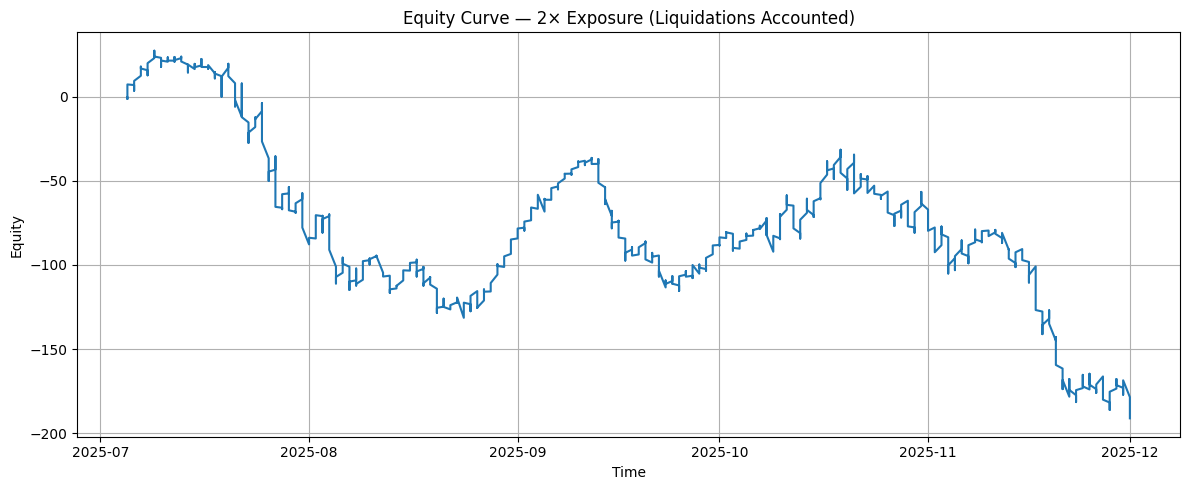


Saved: trades_with_liquidations_2x.csv


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
FILE = "../data/trades_with_liquidations_2x.csv"
df = pd.read_csv(FILE)

# ----------------------------
# BASIC CLEANING
# ----------------------------
df["liquidated"] = df["liquidated"].astype(bool)
df["close_date"] = pd.to_datetime(df["close_date"], utc=True)

# ----------------------------
# HANDLE LIQUIDATIONS EXPLICITLY
# ----------------------------
df["pnl_eur_clean"] = df["pnl_eur"]

# Liquidation = full margin loss
df.loc[df["liquidated"] == True, "pnl_eur_clean"] = (
    -df.loc[df["liquidated"] == True, "position_size"]
)

# ----------------------------
# SANITY CHECKS (VALID ONES)
# ----------------------------
assert not df["pnl_eur_clean"].isna().any(), "NaNs still present!"

# ----------------------------
# SUMMARY STATISTICS
# ----------------------------
total_pnl = df["pnl_eur_clean"].sum()
pnl_no_liq = df.loc[df["liquidated"] == False, "pnl_eur_clean"].sum()
n_liq = int(df["liquidated"].sum())

print("\n=== PNL SUMMARY (2x exposure) ===")
print(f"Total PnL (incl. liquidations): {total_pnl:.2f}")
print(f"PnL excluding liquidations:     {pnl_no_liq:.2f}")
print(f"Number of liquidations:         {n_liq}")

# ----------------------------
# EQUITY CURVE
# ----------------------------
df_sorted = df.sort_values("close_date").copy()

df_sorted["equity"] = df_sorted["pnl_eur_clean"].cumsum()


# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    df_sorted["close_date"].dt.tz_localize(None),
    df_sorted["equity"]
)
plt.xlabel("Time")
plt.ylabel("Equity")
plt.title("Equity Curve — 2× Exposure (Liquidations Accounted)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# SAVE CLEAN OUTPUT
# ----------------------------
df_sorted.to_csv("../data/trades_with_liquidations_2x.csv", index=False)
print("\nSaved: trades_with_liquidations_2x.csv")


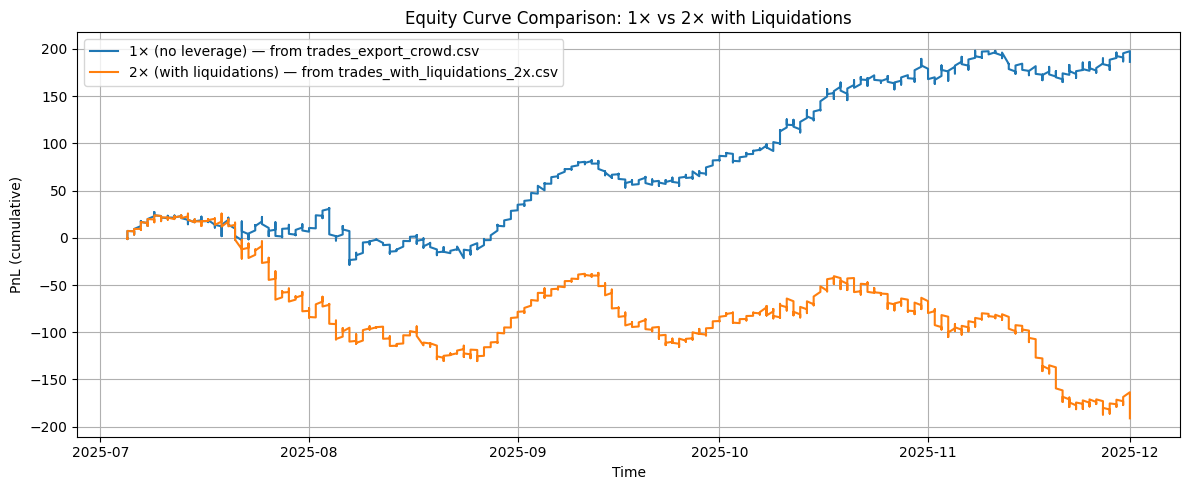

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# FILES
# ----------------------------
TRADES_1X_FILE = "../data/trades_export_crowd.csv"
TRADES_2X_FILE = "../data/trades_with_liquidations_2x.csv"

# ----------------------------
# LOAD 1x (NO LEVERAGE) TRADES
# ----------------------------
df1 = pd.read_csv(TRADES_1X_FILE)

# Parse dates (these are usually date-only strings -> tz-naive is fine)
df1["close_date"] = pd.to_datetime(df1["close_date"], errors="coerce")

# Basic sanity: drop rows without close_date or pnl
df1 = df1.dropna(subset=["close_date", "pnl_eur"]).copy()

# Sort and build equity (start at 0)
df1 = df1.sort_values("close_date").copy()
df1["equity_1x"] = df1["pnl_eur"].cumsum()

# ----------------------------
# LOAD 2x (WITH LIQUIDATIONS) TRADES
# ----------------------------
df2 = pd.read_csv(TRADES_2X_FILE)

df2["liquidated"] = df2["liquidated"].astype(bool)
df2["close_date"] = pd.to_datetime(df2["close_date"], utc=True, errors="coerce")

# If some rows have bad dates, drop them
df2 = df2.dropna(subset=["close_date"]).copy()

# Build pnl_eur_clean: use pnl_eur when not liquidated; full margin loss when liquidated
df2["pnl_eur_clean"] = df2["pnl_eur"]
df2.loc[df2["liquidated"] == True, "pnl_eur_clean"] = -df2.loc[df2["liquidated"] == True, "position_size"]

# Ensure no NaNs remain in pnl_eur_clean
df2["pnl_eur_clean"] = df2["pnl_eur_clean"].fillna(-df2["position_size"])

# Sort and equity (start at 0)
df2 = df2.sort_values("close_date").copy()
df2["equity_2x"] = df2["pnl_eur_clean"].cumsum()

# Convert df2 close_date to tz-naive for plotting consistency
df2["close_date_plot"] = df2["close_date"].dt.tz_localize(None)

# ----------------------------
# PLOT BOTH CURVES
# ----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    df1["close_date"],
    df1["equity_1x"],
    label="1× (no leverage) — from trades_export_crowd.csv"
)

plt.plot(
    df2["close_date_plot"],
    df2["equity_2x"],
    label="2× (with liquidations) — from trades_with_liquidations_2x.csv"
)

plt.xlabel("Time")
plt.ylabel("PnL (cumulative)")
plt.title("Equity Curve Comparison: 1× vs 2× with Liquidations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
